### Build A Basic Chatbot with LangGraph(GRAPH API)

In [20]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [21]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [22]:
import os
from dotenv import load_dotenv

load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: str | ForwardRef('os.PathLike[str]') | None = None, stream: IO[str] | None = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: str | None = 'utf-8') -> bool>

In [23]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [24]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1100aec10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1100af610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### chatbot

In [25]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [26]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

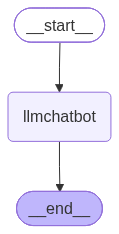

In [27]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
response = graph.invoke({"messages":"Hi"})

In [29]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='3c44cf6b-1bb7-4f23-94f0-0a7056295457'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.052788095, 'completion_tokens_details': None, 'prompt_time': 0.005462184, 'prompt_tokens_details': None, 'queue_time': 0.433532921, 'total_time': 0.058250279}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8358-e610-7e42-a7a3-22dd45141a2e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [30]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

### ChatBot with Tool

In [31]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [32]:
## Custom function
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

In [33]:
tools=[tool,multiply]

In [34]:
llm_with_tool = llm.bind_tools(tools)

In [35]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1100aec10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1100af610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimiz

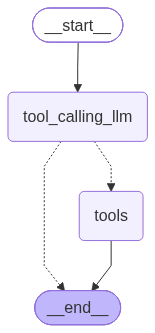

In [36]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

##compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
response=graph.invoke({"messages":"What is the recent AI news"})

In [39]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-07-20/chinese-ai-model-rivals-chatgpt-jolting-silicon-valley", "title": "Chinese AI model rivals ChatGPT, jolting Silicon Valley - Los Angeles Times", "score": 0.65597594, "published_date": "Mon, 20 Jul 2026 17:42:21 GMT", "content": "Another powerful new artificial intelligence model from China took the U.S. tech industry by surprise Friday, the latest sign that Chinese startups that publicly release their “open-source” AI technology are making the California titans of AI sweat. The newest Kimi K3 model from Beijing-based startup Moonshot, run by a Pink Floyd-loving entrepreneur who earned his doctorate in Pittsburgh, appears to be catching up to the best versions of Anthropic’s Claude and OpenAI’s ChatGPT. “This may be the single biggest release of the year,” and marks a moment when open-source Chinese models are surpassing closed U.

In [41]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f6jbj9hb5)
 Call ID: f6jbj9hb5
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-07-20/chinese-ai-model-rivals-chatgpt-jolting-silicon-valley", "title": "Chinese AI model rivals ChatGPT, jolting Silicon Valley - Los Angeles Times", "score": 0.65597594, "published_date": "Mon, 20 Jul 2026 17:42:21 GMT", "content": "Another powerful new artificial intelligence model from China took the U.S. tech industry by surprise Friday, the latest sign that Chinese startups that publicly release their “open-source” A

In [42]:
response=graph.invoke({"messages":"What is 5 multiply by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (hnrg4rczn)
 Call ID: hnrg4rczn
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

null


In [44]:
response=graph.invoke({"messages":"What is recent ai news and then multiply 5 by 2 "})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent ai news and then multiply 5 by 2 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rn97fc3h4)
 Call ID: rn97fc3h4
  Args:
    query: recent ai news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.itnews.com.au/state-of-data-ai-2026/state-of-data-ai-2026-data-sovereignty-compliance-627438", "title": "State of Data & AI 2026: Data Sovereignty & Compliance - iTnews", "score": 0.6708892, "published_date": "Tue, 21 Jul 2026 04:36:29 GMT", "content": "Data sovereignty and compliance have become foundational requirements for enterprise AI, but the challenge facing Australian organisations has evolved well beyond deciding where data

### ReAct Agent Arhitecture

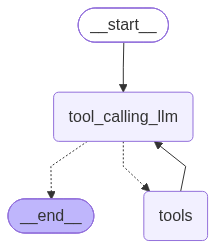

In [45]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
response=graph.invoke({"messages":"What is recent ai news and then multiply 5 by 2 "})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent ai news and then multiply 5 by 2 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (p1tbv9dj0)
 Call ID: p1tbv9dj0
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (n1xspp2mx)
 Call ID: n1xspp2mx
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/20/hugging-face-ai-cyberattack-data-breach", "title": "Hugging Face says an AI agent carried out an end-to-end cyberattack - Axios", "score": 0.657033, "published_date": "Mon, 20 Jul 2026 19:13:19 GMT", "content": "# Hugging Face says AI agent behind internal breach. Hugging Face, a platform that hosts AI models and datasets, says an AI agent 

### Adding Memory in Agentic Graph

In [47]:
response=graph.invoke({"messages":"Hello my name is Dev "})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Dev 
================================== Ai Message ==================================

Hello Dev, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [48]:
response=graph.invoke({"messages":"what is my name? "})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name? 
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to know your personal details or identity. If you'd like to share your name with me, I'd be happy to chat with you, but I won't be able to provide it to you as I don't have that information. Is there anything else I can help you with?


#### Now we will create memory saver checkpoint

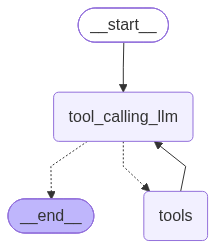

In [49]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi my name is Krish"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='efa111dc-4a2b-482b-bdbf-083a209ca5c4'),
  AIMessage(content="Hello Krish, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1750, 'total_tokens': 1776, 'completion_time': 0.067307296, 'completion_tokens_details': None, 'prompt_time': 0.094088784, 'prompt_tokens_details': None, 'queue_time': 0.161392655, 'total_time': 0.16139608}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f83f4-cb63-7e00-a499-b6bbbbd10435-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 26, 'total_tokens': 1776})]}

In [51]:
response['messages'][-1].content

"Hello Krish, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [55]:
response = graph.invoke({"messages": "Hey, What is my name?"},config=config)
print(response['messages'][-1].content)

Your name is Krish.


### Streaming

In [56]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [57]:
def superbot(state: State):
    return {
        "messages": [llm_with_tool.invoke(state["messages"])]
    }

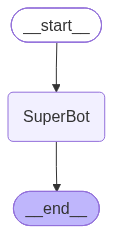

In [58]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [59]:
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages": "Hi, My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c63cc47c-5f42-4d4a-9dcc-bdcb83cea41f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y18j2yek2', 'function': {'arguments': '{"query":"Cricket news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1755, 'total_tokens': 1786, 'completion_time': 0.087323199, 'completion_tokens_details': None, 'prompt_time': 0.091785809, 'prompt_tokens_details': None, 'queue_time': 0.161329979, 'total_time': 0.179109008}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f83fe-eead-7761-ad54-f305c126399d-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Cricket news', 'time_range': 'day', 't

### Streaming

Methods: `.stream()` and `astream()`

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.

In [60]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="That's great! Cricket is a wonderful sport. Are you a fan of any particular team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1755, 'total_tokens': 1777, 'completion_time': 0.066312541, 'completion_tokens_details': None, 'prompt_time': 0.230230195, 'prompt_tokens_details': None, 'queue_time': 0.047797196, 'total_time': 0.296542736}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8427-ecef-7191-ba5d-044b6712d749-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 22, 'total_tokens': 1777})]}}


In [61]:
for chunk in graph_builder.stream({"messages": "Hi, My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='b0012122-f5c2-44e4-81ee-51b761c03518'), AIMessage(content="That's great! Cricket is a wonderful sport. Are you a fan of any particular team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1755, 'total_tokens': 1777, 'completion_time': 0.066312541, 'completion_tokens_details': None, 'prompt_time': 0.230230195, 'prompt_tokens_details': None, 'queue_time': 0.047797196, 'total_time': 0.296542736}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8427-ecef-7191-ba5d-044b6712d749-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 22, 'total_tokens': 1777}), HumanMessage(content='Hi, My name is Krish And I like cricke

#### astream method

In [62]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages": ["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f886a-a926-7081-b763-e861fb0bc910', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='220f9ede-27f5-47a7-94c4-659d5b1a5034')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f886a-a958-72b2-97eb-54be11afc72d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:25deb914-17e7-d2be-2a36-f6a376dc2e45'}, 'parent_ids': ['019f886a-a926-7081-b763-e861fb0bc910']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':